# Kaggle DistilBERT Baseline

This notebook fine-tunes a pre-trained DistilBERT model for binary phishing email classification on the Kaggle human and LLM-generated email dataset. The resulting metrics are stored in the shared results CSV so they can be compared directly against the classical and deep learning baselines.

## 1. Import Libraries

All libraries needed for data loading, tokenisation, model training, evaluation, and results persistence are imported here.

In [1]:
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# HuggingFace Transformers
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
)

# Sklearn metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# Visualisation
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Reproducibility and Configuration

All random seeds are fixed at 42 and every training hyper-parameter is defined as an ALL_CAPS constant so that results can be exactly reproduced and hyper-parameters are easy to find and adjust.

In [2]:
# Configuration constants
SEED          = 42
MODEL_NAME    = "distilbert-base-uncased"
MAX_LEN       = 256
BATCH_SIZE    = 16
LEARNING_RATE = 2e-5
NUM_EPOCHS    = 5
WARMUP_RATIO  = 0.1
WEIGHT_DECAY  = 1e-2
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

data_dir    = Path("../data/processed/kaggle/")
results_dir = Path("../results/")
results_dir.mkdir(parents=True, exist_ok=True)

# Fix all random seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Device: {DEVICE}")

Device: cpu


## 3. Load Processed Data

The train and test Parquet files produced by the Kaggle preparation notebook are loaded here. These contain the cleaned `text`, `label`, and `source` columns.

In [3]:
# Load the 60% training split
train_df = pd.read_parquet(data_dir / "kaggle_train_60.parquet")

# Load the 40% test split
test_df = pd.read_parquet(data_dir / "kaggle_test_40.parquet")

print(f"Train size: {len(train_df)} rows")
print(f"Test size:  {len(test_df)} rows")
print(f"Columns: {train_df.columns.tolist()}")

Train size: 1435 rows
Test size:  957 rows
Columns: ['text', 'label', 'source']


## 4. Verify Loaded Data

A quick check to confirm the data loaded correctly, the label distribution is preserved, and sample rows look as expected before fine-tuning begins.

In [4]:
# Preview the first 3 rows to confirm structure looks correct
print(train_df[["text", "label"]].head(3))
print()

# Confirm label balance matches the full dataset
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

                                                text  label
0          Rachel Thompson COVID-19 Vaccination Team      1
1  Notification: jose@monkey.org Dear jose   To c...      1
2  ActiveState evaluation license for Komodo IDE ...      0

Train label distribution:
label
0    1034
1     401
Name: count, dtype: int64

Test label distribution:
label
0    690
1    267
Name: count, dtype: int64


## 5. Tokenisation

The DistilBERT tokenizer is loaded from pre-trained weights and applied to each email, truncating to `MAX_LEN=256` tokens and padding shorter sequences to the same length. The tokenizer is never fit on the data — all vocabulary knowledge comes from pre-training.

In [5]:
# Load DistilBERT tokenizer from pretrained weights — no fitting on data
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# Sanity check: tokenise one example to confirm truncation and padding
sample = tokenizer(
    train_df["text"].iloc[0],
    truncation=True,
    max_length=MAX_LEN,
    padding="max_length",
    return_tensors="pt",
)
print(f"Sample input_ids shape    : {sample['input_ids'].shape}")
print(f"Sample attention_mask shape: {sample['attention_mask'].shape}")

Sample input_ids shape    : torch.Size([1, 256])
Sample attention_mask shape: torch.Size([1, 256])


## 6. PyTorch Dataset and DataLoaders

A custom `EmailDataset` class tokenises each email on demand and returns the three tensors that DistilBERT expects. A random 10% validation split is carved out of the training set before building the loaders.

In [6]:
class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt",
        )
        return (
            encoding["input_ids"].squeeze(0),
            encoding["attention_mask"].squeeze(0),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )


# Hold out a random 10% of training data as a validation set
# Using random sampling avoids row-order bias in the validation set
val_sub   = train_df.sample(frac=0.1, random_state=SEED)
train_sub = train_df.drop(val_sub.index).reset_index(drop=True)
val_sub   = val_sub.reset_index(drop=True)

train_dataset = EmailDataset(
    train_sub["text"].tolist(), train_sub["label"].tolist(), tokenizer, MAX_LEN
)
val_dataset = EmailDataset(
    val_sub["text"].tolist(), val_sub["label"].tolist(), tokenizer, MAX_LEN
)
test_dataset = EmailDataset(
    test_df["text"].tolist(), test_df["label"].tolist(), tokenizer, MAX_LEN
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 81
Val   batches : 9
Test  batches : 60


## 7. Model Definition

The pre-trained `distilbert-base-uncased` checkpoint is loaded with a two-class classification head and moved onto the target device.

> **Why DistilBERT?** DistilBERT is a distilled version of BERT-base that is 60% smaller and roughly 2× faster at inference while retaining approximately 97% of BERT's language understanding performance on downstream tasks (Sanh et al., 2019). This makes it a meaningful addition to the baseline suite: it shows how a lightweight transformer compares to the classical and recurrent models at a deployment-relevant speed–accuracy trade-off.

In [7]:
# Load DistilBERT with a two-class classification head
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 66,955,010


## 8. Training and Evaluation Functions

Three helper functions encapsulate the training loop, evaluation logic, and inference timing so that the main training cell remains readable.

In [8]:
from tqdm.auto import tqdm

def train_epoch(model, loader, optimiser, scheduler, criterion, device):
    """Run one full training pass over the loader and return average loss."""
    model.train()
    total_loss = 0.0
    all_labels, all_preds = [], []
    for input_ids, attention_mask, labels in tqdm(loader, desc="Training", leave=False):
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels         = labels.to(device)

        optimiser.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels)
        loss.backward()
        optimiser.step()
        scheduler.step()
        total_loss += loss.item()

        preds = outputs.logits.argmax(dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


def evaluate(model, loader, criterion, device):
    """Evaluate the model over the loader; return loss and all classification metrics."""
    model.eval()
    total_loss = 0.0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for input_ids, attention_mask, labels in tqdm(loader, desc="Evaluating", leave=False):
            input_ids      = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels         = labels.to(device)

            outputs    = model(input_ids=input_ids, attention_mask=attention_mask)
            loss       = criterion(outputs.logits, labels)
            total_loss += loss.item()

            preds = outputs.logits.argmax(dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    prec     = precision_score(all_labels, all_preds, zero_division=0)
    rec      = recall_score(all_labels, all_preds, zero_division=0)
    f1       = f1_score(all_labels, all_preds, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    return avg_loss, acc, prec, rec, f1, fpr, all_labels, all_preds


def measure_inference_time(model, loader, device, n_runs=3):
    """Measure model-only inference time, excluding DataLoader overhead.
    Pre-converts the full test set to single tensors so that batch
    construction and data-transfer costs are not included in the timing."""
    model.eval()

    # Pre-collect all batches into single tensors to exclude DataLoader overhead
    all_ids, all_masks = [], []
    for input_ids, attention_mask, _ in tqdm(loader, desc="Stacking inputs", leave=False):
        all_ids.append(input_ids)
        all_masks.append(attention_mask)
    all_ids   = torch.cat(all_ids,   dim=0).to(device)
    all_masks = torch.cat(all_masks, dim=0).to(device)

    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            start = time.perf_counter()
            _ = model(input_ids=all_ids, attention_mask=all_masks)
            end   = time.perf_counter()
            times.append((end - start) * 1000)  # ms

    # Average across runs, then divide by number of emails
    return round(np.mean(times) / len(all_ids), 4)

## 9. Train Model

AdamW with weight decay and a linear warmup schedule are used to fine-tune the model. Validation loss, accuracy, F1, and FPR are printed at the end of each epoch to monitor learning progress.

In [9]:
# Instantiate AdamW optimiser with weight decay
optimiser = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# Linear warmup + linear decay scheduler
total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimiser,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

criterion = nn.CrossEntropyLoss()

# Training history for plotting
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    
    t0 = time.time()
    train_loss, train_acc = train_epoch(
        model, train_loader, optimiser, scheduler, criterion, DEVICE
    )
    val_loss, val_acc, _, _, val_f1, val_fpr, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )
    t1 = time.time()
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    elapsed = t1 - t0
    ms_step = int((elapsed * 1000) / len(train_loader))
    batches = len(train_loader)
    print(f"{batches}/{batches} - {elapsed:.0f}s {ms_step}ms/step - "
          f"accuracy: {train_acc:.4f} - loss: {train_loss:.4f} - "
          f"val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f}")


Epoch 1/5
81/81 - 195s 2412ms/step - accuracy: 0.8203 - loss: 0.3604 - val_accuracy: 0.9931 - val_loss: 0.0763
Epoch 2/5
81/81 - 192s 2376ms/step - accuracy: 0.9915 - loss: 0.0496 - val_accuracy: 0.9931 - val_loss: 0.0360
Epoch 3/5
81/81 - 174s 2143ms/step - accuracy: 0.9938 - loss: 0.0237 - val_accuracy: 0.9931 - val_loss: 0.0400
Epoch 4/5
81/81 - 159s 1965ms/step - accuracy: 0.9992 - loss: 0.0067 - val_accuracy: 0.9931 - val_loss: 0.0380
Epoch 5/5
81/81 - 169s 2084ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 0.9931 - val_loss: 0.0395


## 10. Final Test Evaluation

The trained model is evaluated on the held-out test set. FPR and inference time are included alongside the standard classification metrics so that results can be compared directly with every other model in the project.

In [10]:
test_loss, test_acc, test_prec, test_rec, test_f1, test_fpr, true_labels, pred_labels = evaluate(
    model, test_loader, criterion, DEVICE
)
# Measure inference time; function returns avg ms / email
test_inf_ms = measure_inference_time(model, test_loader, DEVICE)
# Convert to per-email seconds and total seconds over the test set
test_inf_per_email_sec = round(test_inf_ms / 1000, 6)
test_inf_total_sec     = round(test_inf_per_email_sec * len(test_df), 4)

print("DistilBERT Classification Report:")
print(classification_report(true_labels, pred_labels, target_names=["Legitimate (0)", "Phishing (1)"]))
print(f"False Positive Rate (FPR): {test_fpr:.4f}")
print(f"Inference time (s/email): {test_inf_per_email_sec}")

results_distilbert = {
    "dataset":                   "Kaggle",
    "model":                     "DistilBERT",
    "accuracy":                  round(test_acc,  4),
    "precision":                 round(test_prec, 4),
    "recall":                    round(test_rec,  4),
    "f1":                        round(test_f1,   4),
    "false_positive_rate":       round(test_fpr,  4),
    "inference_time_total_sec":  test_inf_total_sec,
    "inference_time_per_email_sec": test_inf_per_email_sec,
    "train_rows":                1435,
    "test_rows":                 957,
    "vocab_size":                tokenizer.vocab_size,
}

DistilBERT Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       0.99      1.00      0.99       690
  Phishing (1)       0.99      0.97      0.98       267

      accuracy                           0.99       957
     macro avg       0.99      0.98      0.99       957
  weighted avg       0.99      0.99      0.99       957

False Positive Rate (FPR): 0.0029
Inference time (s/email): 0.02362


## 11. Confusion Matrix

The confusion matrix visualises which emails were correctly and incorrectly classified, making it easy to see whether false positives or false negatives dominate the errors.

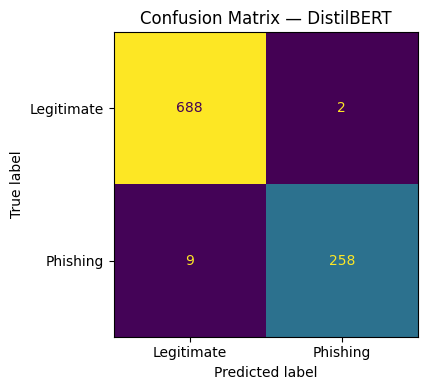

Confusion matrix saved.


In [11]:
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix \u2014 DistilBERT")
plt.tight_layout()
# Ensure figures subdirectory exists
figures_dir = results_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "kaggle_cm_distilbert.png", dpi=150)
plt.show()
print("Confusion matrix saved.")

## 12. Training Curves

Training and validation loss alongside validation F1 are plotted across epochs to visualise how quickly the model converges and whether it is overfitting.

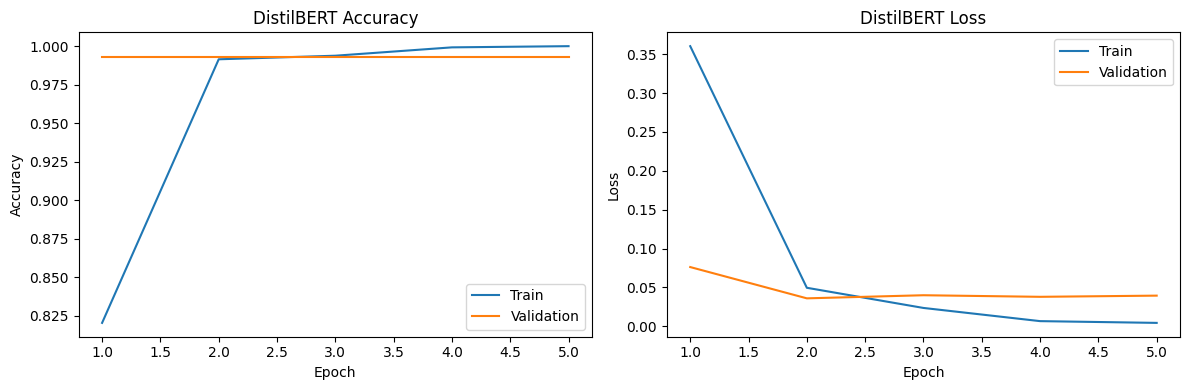

Training curves saved.


In [13]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_acc"], label="Train")
axes[0].plot(epochs, history["val_acc"], label="Validation")
axes[0].set_title("DistilBERT Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs, history["train_loss"], label="Train")
axes[1].plot(epochs, history["val_loss"], label="Validation")
axes[1].set_title("DistilBERT Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
# figures_dir is defined in the confusion-matrix cell above
plt.savefig(figures_dir / "kaggle_distilbert_training_curves.png", dpi=150)
plt.show()
print("Training curves saved.")

## 13. Save Results

The final metrics are appended to `kaggle_results.csv` so they can be included in the project-wide comparison table. The file is created with a header on the first run and appended without a header on subsequent runs.

In [14]:
# Ensure metrics subdirectory exists
metrics_dir = results_dir / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

save_path  = metrics_dir / "kaggle_distilbert_results.csv"
results_df = pd.DataFrame([results_distilbert])

# Save with index=True as required by project convention
results_df.to_csv(save_path, index=True)

print(f"Results saved to {save_path}")
results_df

Results saved to ../results/metrics/kaggle_distilbert_results.csv


,dataset,model,accuracy,precision,recall,f1,false_positive_rate,inference_time_total_sec,inference_time_per_email_sec,train_rows,test_rows,vocab_size
0,Kaggle,DistilBERT,0.9885,0.9923,0.9663,0.9791,0.0029,22.6043,0.02362,1435,957,30522
